# Introduction

In this notebook we first evaluate the performance of unimodal MLPs trained using [DINOv2](https://github.com/facebookresearch/dinov2) and [ResNet-18](https://pytorch.org/hub/pytorch_vision_resnet/) embeddings derived from multiple [LeafMachine 3](https://www.leafmachine.org/) products. We then select the best performing ResNet-18 CNNs to test multimodal performance using a late fusion two-tower approach.

# Set up colab environment

This notebook was designed to run on [Google Colab](https://colab.research.google.com/) and run using a T4 Python 3 runtime

The code in this notebook is written with the expectation that files are found in a Google Drive folder called called `hypeRGB/` Running the following cell should request permissions to mount a google drive account, and this folder should then be visible to the colab notebook as: `/content/drive/MyDrive/hypeRGB`

**Note**: this notebook was written for data exploration as part of our hackathon, and it does not run efficiently on colab, due to file I/O limitations from Google Drive, as well as resource limitations on the free tier. It is presented here as-is, in the spirit of reproducibility from our hackathon.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This folder `/content/drive/MyDrive/hypeRGB` should contain the following folders containing products from LeafMachine 3 processing of herbarium sheet RGB images, as well as a set of metadata CSV files used for sample processing.

| Name | Description |
| ---- | ----------- |
| Lamina_RGB/ | Oriented, segmented leaf images from LeafMachine |
| Lamina_RGB__dinov2embeddings/ | DINOv2 embeddings from above |
| Leaf_BBox/ | Leaf bounding box images from LeafMachine |
| Leaf_BBox__dinov2embeddings/ | DINOv2 embeddings from above |
| Oriented_Leaf_ECT/ | Euler Characteristic Transform images from LeafMachine |
| Oriented_Leaf_ECT__dinov2embeddings/ | DINOv2 embeddings from above |
| RGB_Masks_Specimen/ | Full specimen segmented images from LeafMachine |
| RGB_Masks_Specimen__dinov2embeddings/ | DINOv2 embeddings from above |
| metadata_v2.csv | Metadata for all samples |
| metadata_test_v2.csv | Test split for samples |
| metadata_train_v2.csv | Training split for samples |
| metadata_grasses_test_v2.csv | Samples to optionally censor from test split |
| metadata_grasses_train_v2.csv | Samples to optionally censor from training split |

Additionally, the code below will cache the DINOv2 embeddings in, for example, `Lamina_RGB__dinov2embeddings/` to avoid having to re-generate the embeddings each time.

**Note**: the `*_grasses_*` files are used optionally to remove samples from the test/train splits in several sections below, with parameters named, for e.g. `EXCLUDE_GRASSES`. Despite the name, this also includes several species of ferns. The rationale for exclusion is that grasses and ferns have large fundamental differences from many of the other species present. Based on the tests below, using just the RGB images there does not appear to be a substantial impact on accuracy from the inclusion of these species in the testing and training of the classifiers.

In [2]:
# ======================================================================
# SETUP — Colab environment (uncomment to run in Colab)
# ======================================================================
!pip install torch torchvision
!pip install umap-learn scikit-learn matplotlib pillow


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import umap
from PIL import Image
from pathlib import Path
from sklearn.manifold import TSNE
from torchvision import transforms
from sklearn.decomposition import PCA
from tqdm.auto import tqdm # note: if running with Jupyter Lab (not colab) use "from tqdm.autonotebook import tqdm as notebook_tqdm"
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader

# Use GPU if available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", DEVICE)


Using: cuda


In [4]:
# ======================================================================
# SECTION 0 — Map image file names to species names
# ======================================================================
# Images are named by the "specimenId" column.
# The species label is built as: order_family_genus_species
# (all lowercase, spaces in species replaced with underscores).

meta = pd.read_csv("/content/drive/MyDrive/hypeRGB/metadata_v2.csv")

def make_label(row):
    # "species" column holds "Genus species"; keep just the species epithet
    epithet = str(row["species"]).strip().split(" ")[1]
    parts = [row["order"], row["family"], row["genus"], epithet]
    return "_".join(str(p).strip() for p in parts).lower()

meta["label"] = meta.apply(make_label, axis=1)
name_to_species = dict(zip(meta["specimenId"].astype(str), meta["label"]))

# Helper: get species from an image file path
def species_of(image_path):
    stem = Path(image_path).stem   # file name without extension
    if "__" in stem:               # take the specimenId before the "__"
        stem = stem.split("__")[0]
        stem = stem.lstrip("0")
    return name_to_species.get(stem, "unknown").lstrip("0")

def image_key(p):
    stem = Path(p).stem
    stem = stem.split("__")[0] if "__" in stem else stem
    return stem.lstrip("0")

print(name_to_species['289421'])


fagales_myricaceae_myrica_gale


# DINOv2

In [5]:
# ======================================================================
# SECTION 1 — Load DINOv2
# ======================================================================
# Load a pretrained DINOv2 model from torch hub.
# Options: dinov2_vits14 (small), dinov2_vitb14 (base), dinov2_vitl14 (large)

model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
model = model.to(DEVICE).eval()

PATCH = 14          # DINOv2 patch size
IMG_SIZE = 224      # must be a multiple of PATCH
EMBED_DIM = 384     # output dim for vits14 (base=768, large=1024)


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 262MB/s]


In [6]:
# ======================================================================
# SECTION 2 — Preprocess helper
# ======================================================================
# Turn an image file into a normalized tensor DINOv2 expects.

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def load_tensor(image_path):
    img = Image.open(image_path).convert("RGB")
    return preprocess(img).unsqueeze(0).to(DEVICE)   # shape [1, 3, 224, 224]


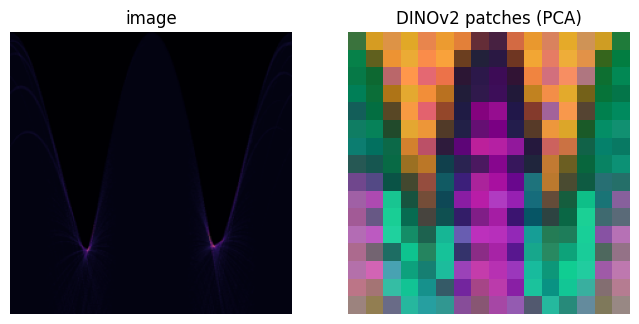

In [7]:
# ======================================================================
# SECTION 3 — Run one image and visualize its patch embeddings with PCA
# ======================================================================
# DINOv2 splits the image into a grid of patches and gives each an embedding.
# We reduce each patch embedding to 3 values (PCA) and show them as RGB.



#image_path = "/content/drive/MyDrive/hypeRGB/RGB_Masks_Specimen/00289421__MaskRGBFull-specimen.jpg"   # <-- set to one of your image files
image_path = "/content/drive/MyDrive/hypeRGB/Oriented_Leaf_ECT/00289421__ECT__520_1450_926_1793.png"   # <-- set to one of your image files
#image_path = "/content/drive/MyDrive/hypeRGB/Lamina_RGB/00289421__or-RGB-lamina__520_1450_926_1793.jpg"
x = load_tensor(image_path)

with torch.no_grad():
    out = model.forward_features(x)
    patch_tokens = out["x_norm_patchtokens"][0]   # shape [num_patches, EMBED_DIM]

patches = patch_tokens.cpu().numpy()
grid = IMG_SIZE // PATCH   # 16 patches per side

# PCA the patch embeddings down to 3 channels
pca = PCA(n_components=3)
rgb = pca.fit_transform(patches)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())   # scale to 0..1
rgb = rgb.reshape(grid, grid, 3)

# Show original next to the PCA "activation" image
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
ax[0].set_title("image"); ax[0].axis("off")
ax[1].imshow(rgb); ax[1].set_title("DINOv2 patches (PCA)"); ax[1].axis("off")
plt.show()


In [8]:
# ======================================================================
# SECTION 4 — Store one image embedding as a variable
# ======================================================================
# The CLS token is a single vector summarizing the whole image.

def embed(image_path):
    x = load_tensor(image_path)
    with torch.no_grad():
        vec = model(x)          # calling model directly returns the CLS embedding
    return vec[0].cpu().numpy()  # shape [EMBED_DIM]

single_embedding = embed(image_path)
print("embedding shape:", single_embedding.shape)



embedding shape: (384,)


In [10]:
# ======================================================================
# SECTION 5 — Embed image folders (cached) and plot a 2D UMAP
# ======================================================================
# Embeds several image folders with DINOv2. Each embedding is cached as a
# per-image .npy in a sibling "<folder>__dinov2embeddings" dir, so a Colab
# restart just reloads them instead of recomputing.


SOURCE_DIRS = [
    "/content/drive/MyDrive/hypeRGB/Lamina_RGB",
    "/content/drive/MyDrive/hypeRGB/Leaf_BBox",
    "/content/drive/MyDrive/hypeRGB/Oriented_Leaf_ECT",
    "/content/drive/MyDrive/hypeRGB/RGB_Masks_Specimen",
]

# Dataset: loads + preprocesses one image (workers do this in parallel)
class ImageDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return preprocess(img)   # [3, 224, 224]

# Embed a whole batch on the GPU at once (fp16 on CUDA for speed)
@torch.inference_mode()
def embed_batch(batch):
    batch = batch.to(DEVICE, non_blocking=True)
    if DEVICE == "cuda":
        with torch.autocast("cuda", dtype=torch.float16):
            out = model(batch)           # CLS embedding per image
    else:
        out = model(batch)
    return out.float().cpu().numpy()

# Embed one folder, using cached .npy files when present
def embed_dir(image_dir, batch_size=64, num_workers=0):
    image_dir = Path(image_dir)
    out_dir = image_dir.parent / (image_dir.name + "__dinov2embeddings")
    out_dir.mkdir(exist_ok=True)

    paths = sorted([p for p in image_dir.rglob("*")
                    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    assert len(paths) > 0, f"No images found under {image_dir} — check the path"

    # Only compute the ones we haven't cached yet
    todo = [p for p in paths if not (out_dir / (p.stem + ".npy")).exists()]
    if todo:
        loader = DataLoader(ImageDataset(todo), batch_size=batch_size,
                            num_workers=num_workers, pin_memory=(DEVICE == "cuda"))
        k = 0
        for batch in tqdm(loader, desc=image_dir.name):
            for v in embed_batch(batch):
                np.save(out_dir / (todo[k].stem + ".npy"), v)   # cache to Drive
                k += 1

    # Load everything (cached + just-computed) in path order
    embeddings = np.array([np.load(out_dir / (p.stem + ".npy")) for p in paths])
    labels = [species_of(p) for p in paths]
    return paths, embeddings, labels

# Embed (or load) every folder
datasets = {}
for d in SOURCE_DIRS:
    ps, embs, labs = embed_dir(d)
    datasets[Path(d).name] = (ps, embs, labs)
    print(f"{Path(d).name}: {len(ps)} images")




Lamina_RGB: 8942 images
Leaf_BBox: 9042 images
Oriented_Leaf_ECT: 8942 images
RGB_Masks_Specimen: 452 images


active dataset: Oriented_Leaf_ECT (8942, 384)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


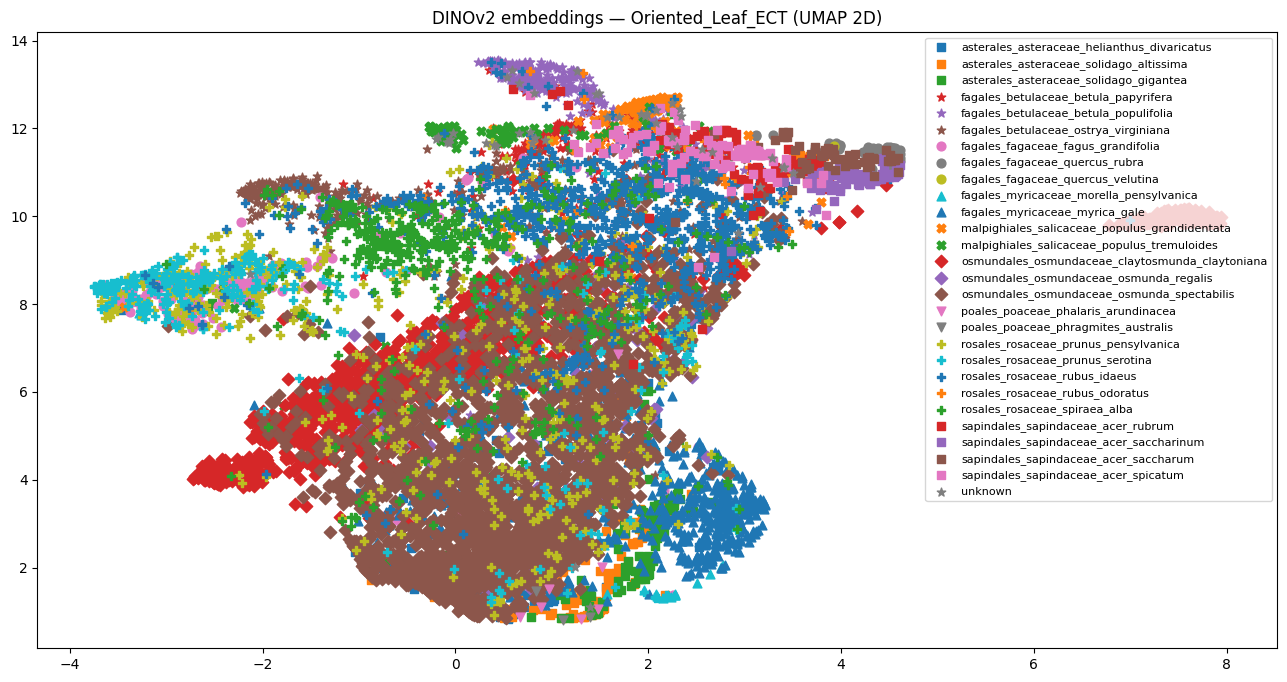

In [11]:
# Pick which folder to use downstream (Section 6)
#   RGB_Masks_Specimen ~ 450
#   Oriented_Leaf_ECT ~ 9,000
#   Leaf_BBox ~ 9,000
#   Lamina_RGB ~ 9,000
ACTIVE = "Oriented_Leaf_ECT"
paths, embeddings, labels = datasets[ACTIVE]
print("active dataset:", ACTIVE, embeddings.shape)

# Reduce embeddings to 2D
coords = umap.UMAP(n_components=2, random_state=42).fit_transform(embeddings)

# Family is the 2nd part of the label (order_family_genus_species)
def family_of(label):
    return label.split("_")[1] if label != "unknown" else "unknown"

# Assign a marker shape per family
markers = ["s", "*", "o", "^", "D", "v", "P", "X"]   # square, asterisk, circle...
families = sorted(set(family_of(l) for l in labels))
family_marker = {f: markers[i % len(markers)] for i, f in enumerate(families)}

# Plot: color by species, marker shape by family
plt.figure(figsize=(16, 8))
for sp in sorted(set(labels)):
    idx = [i for i, l in enumerate(labels) if l == sp]
    plt.scatter(coords[idx, 0], coords[idx, 1], label=sp, s=40,
                marker=family_marker[family_of(sp)])
plt.legend(fontsize=8); plt.title(f"DINOv2 embeddings — {ACTIVE} (UMAP 2D)")
plt.show()

In [12]:
BASE = "/content/drive/MyDrive/hypeRGB/"
train_csv   = pd.read_csv(BASE + "metadata_train_v2.csv")
test_csv    = pd.read_csv(BASE + "metadata_test_v2.csv")
grass_train = pd.read_csv(BASE + "metadata_train_grasses_v2.csv")
grass_test  = pd.read_csv(BASE + "metadata_test_grasses_v2.csv")

# Images are named by specimenId, so we split at the specimenId level.
# specimenId as str(int) has no leading zeros -> matches image_key() below.
def id_set(df):
    return set(df["specimenId"].astype(str))

train_ids = id_set(train_csv)
test_ids  = id_set(test_csv)
grass_ids = id_set(grass_train) | id_set(grass_test)

# A specimenId can appear in both CSVs (split is per-measurement); test wins,
# so no specimen leaks across train and test.
train_ids = train_ids - test_ids

In [13]:
# ======================================================================
# SECTION 6 — Train an MLP classifier using the predefined train/test split
# ======================================================================
# The split is given by CSV files. We build two dataset variants:
#   (A) ALL species
#   (B) ALL species EXCEPT grasses (the grasses CSVs are used only to exclude)


# Get the specimenId key from an image path (matches species_of)
def image_key(p):
    stem = Path(p).stem
    stem = stem.split("__")[0] if "__" in stem else stem
    return stem.lstrip("0")   # image files keep leading zeros; the ids do not

# Assign each embedded image to train/test using the CSV specimenId splits.
# Labels reuse `labels` (species_of) computed in Section 5.
def build_split(exclude_grasses):
    Xtr, ytr, Xte, yte = [], [], [], []
    for emb, p, lab in zip(embeddings, paths, labels):
        key = image_key(p)
        if lab == "unknown":
            continue
        if exclude_grasses and key in grass_ids:
            continue
        if key in test_ids:
            Xte.append(emb); yte.append(lab)
        elif key in train_ids:
            Xtr.append(emb); ytr.append(lab)
    return np.array(Xtr), ytr, np.array(Xte), yte

# Train a small MLP on one variant and print test accuracy
def train_eval(X_train, y_train_lab, X_test, y_test_lab, title):
    le = LabelEncoder().fit(y_train_lab + y_test_lab)
    y_train = le.transform(y_train_lab)
    y_test  = le.transform(y_test_lab)

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(DEVICE)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(DEVICE)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long).to(DEVICE)

    clf = nn.Sequential(
        nn.Linear(EMBED_DIM, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, len(le.classes_)),
    ).to(DEVICE)

    optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(100):
        clf.train()
        optimizer.zero_grad()
        loss = loss_fn(clf(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

    clf.eval()
    with torch.no_grad():
        logits = clf(X_test_t)
        y_pred_t = logits.argmax(1)

        acc = (y_pred_t == y_test_t).float().mean().item()


    print(f"{title}: {len(y_train_lab)} train / {len(y_test_lab)} test, "
        f"{len(le.classes_)} classes, test accuracy {acc:.2%}")

# Variant A: everything
Xtr, ytr, Xte, yte = build_split(exclude_grasses=False)
train_eval(Xtr, ytr, Xte, yte, "ALL species")

# Variant B: everything except grasses
Xtr, ytr, Xte, yte = build_split(exclude_grasses=True)
train_eval(Xtr, ytr, Xte, yte, "NO grasses")


ALL species: 4907 train / 1811 test, 23 classes, test accuracy 67.09%
NO grasses: 2995 train / 997 test, 20 classes, test accuracy 65.10%


# ResNet-18

In [14]:
# ======================================================================
# SECTION 7 — Train a small CNN (ResNet-18) on the raw images
# ======================================================================
# A different approach: instead of DINOv2 embeddings, fine-tune a small CNN
# directly on the images. Uses the SAME specimenId train/test split as
# Section 6 (run Sections 5 and 6 first). Pick which image folder to use.


# Pick which folder to use downstream (Section 6)
#   RGB_Masks_Specimen ~ 450
#   Oriented_Leaf_ECT ~ 9,000
#   Leaf_BBox ~ 9,000
#   Lamina_RGB ~ 9,000

CNN_DATASET = "Oriented_Leaf_ECT"     # one of the SOURCE_DIRS folder names
EXCLUDE_GRASSES = False        # match Section 6's two variants if you want
FINETUNE = False               # False = train only the new head (fast);
                               # True  = fine-tune the whole ResNet (slower)
EPOCHS = 10
BATCH = 32

# Reuse the paths + labels already gathered in Section 5
paths_c, _, labels_c = datasets[CNN_DATASET]

# Split image paths into train/test using the CSV specimenId sets (Section 6)
def split_paths(paths, labels, exclude_grasses):
    tr_p, tr_y, te_p, te_y = [], [], [], []
    for p, lab in zip(paths, labels):
        key = image_key(p)
        if lab == "unknown":
            continue
        if exclude_grasses and key in grass_ids:
            continue
        if key in test_ids:
            te_p.append(p); te_y.append(lab)
        elif key in train_ids:
            tr_p.append(p); tr_y.append(lab)
    return tr_p, tr_y, te_p, te_y

tr_p, tr_y, te_p, te_y = split_paths(paths_c, labels_c, EXCLUDE_GRASSES)
print(f"{CNN_DATASET}: {len(tr_p)} train / {len(te_p)} test images")

# Encode species names to integers
le = LabelEncoder().fit(tr_y + te_y)

# Dataset: raw image tensor + integer label
class LeafDataset(Dataset):
    def __init__(self, paths, labs):
        self.paths = paths
        self.y = le.transform(labs)
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return preprocess(img), int(self.y[i])

train_loader = DataLoader(LeafDataset(tr_p, tr_y), batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE == "cuda"))
test_loader  = DataLoader(LeafDataset(te_p, te_y), batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE == "cuda"))

# ResNet-18 pretrained on ImageNet, with a new head for our species
cnn = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze the backbone unless we're fine-tuning
if not FINETUNE:
    for p in cnn.parameters():
        p.requires_grad = False

cnn.fc = nn.Linear(cnn.fc.in_features, len(le.classes_))   # new head is always trainable
cnn = cnn.to(DEVICE)

# Fine-tuning the whole net wants a smaller LR than training just the head
lr = 1e-4 if FINETUNE else 1e-3
trainable = [p for p in cnn.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable, lr=lr)
loss_fn = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

# Train (fp16 autocast for speed on the T4)
for epoch in range(EPOCHS):
    cnn.train()
    running = 0.0
    for xb, yb in tqdm(train_loader, desc=f"epoch {epoch+1}/{EPOCHS}"):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            loss = loss_fn(cnn(xb), yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item() * xb.size(0)
    print(f"  train loss {running/len(tr_p):.3f}")

# Evaluate on the held-out test images
cnn.eval()
correct = 0
with torch.inference_mode():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            preds = cnn(xb).argmax(1)
        correct += (preds == yb).sum().item()
acc = correct / len(te_p)
print(f"{CNN_DATASET} ResNet-18 test accuracy: {acc:.2%} ({len(le.classes_)} classes)")


Oriented_Leaf_ECT: 4907 train / 1811 test images
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


epoch 1/10:   0%|          | 0/154 [00:00<?, ?it/s]

  train loss 1.690


epoch 2/10:   0%|          | 0/154 [00:00<?, ?it/s]

...

  train loss 0.712


epoch 9/10:   0%|          | 0/154 [00:00<?, ?it/s]

  train loss 0.691


epoch 10/10:   0%|          | 0/154 [00:00<?, ?it/s]

  train loss 0.664
Oriented_Leaf_ECT ResNet-18 test accuracy: 69.69% (23 classes)


# Testing multimodal approach

In [15]:
# ======================================================================
# SECTION 8 — Two-tower CNN with late fusion
# ======================================================================
# Two image types (e.g. lamina_RGB + ECT) each go through their own
# ResNet-18 "tower". We concatenate the two feature vectors (late fusion) and
# classify with an MLP. Uses the same specimenId split (run Sections 5 and 6).
#
#   Image A ─► CNN A ─► zA ─┐
#                           ├─► concat ─► MLP ─► classes
#   Image B ─► CNN B ─► zB ─┘



HYPERGB = "/content/drive/MyDrive/hypeRGB/"   # folder holding the image subfolders
TOWER_A_DATASET = "Lamina_RGB"           # image type for tower A
TOWER_B_DATASET = "Oriented_Leaf_ECT"   # image type for tower B
PRETRAINED = True                        # start towers from ImageNet weights?
EXCLUDE_GRASSES = False
EPOCHS = 10
BATCH = 32

# One ResNet-18 with its classifier head removed -> outputs a feature vector
class Tower(nn.Module):
    def __init__(self, pretrained):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)
        self.out_dim = backbone.fc.in_features   # 512 for resnet18
        backbone.fc = nn.Identity()              # swap the head for a pass-through
        self.backbone = backbone
    def forward(self, x):
        return self.backbone(x)                  # [B, 512]

# Two towers + an MLP over the concatenated features
class TwoTowerNet(nn.Module):
    def __init__(self, n_classes, pretrained):
        super().__init__()
        self.tower_a = Tower(pretrained)         # CNN A
        self.tower_b = Tower(pretrained)         # CNN B (separate weights)
        fused_dim = self.tower_a.out_dim + self.tower_b.out_dim   # 512 + 512
        # New layers: an MLP head that takes the fused vector
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, n_classes),
        )
    def forward(self, xa, xb):
        za = self.tower_a(xa)                     # feature vector from image A
        zb = self.tower_b(xb)                     # feature vector from image B
        z = torch.cat([za, zb], dim=1)           # late fusion = concatenate
        return self.classifier(z)

# --- Train/test split + labels, read straight from the CSVs (standalone) ---
BASE = HYPERGB + "/"
train_csv   = pd.read_csv(BASE + "metadata_train_v2.csv")
test_csv    = pd.read_csv(BASE + "metadata_test_v2.csv")
grass_train = pd.read_csv(BASE + "metadata_train_grasses_v2.csv")
grass_test  = pd.read_csv(BASE + "metadata_test_grasses_v2.csv")

# specimenId sets for each split (str(int) has no leading zeros)
def id_set(df):
    return set(df["specimenId"].astype(str))

test_ids  = id_set(test_csv)
train_ids = id_set(train_csv) - test_ids   # test wins if a specimen is in both
grass_ids = id_set(grass_train) | id_set(grass_test)

# Build specimenId -> species label (order_family_genus_species) from the CSVs
def make_label(row):
    epithet = str(row["species"]).strip().split(" ")[1]   # "Genus species" -> species
    parts = [row["order"], row["family"], row["genus"], epithet]
    return "_".join(str(x).strip() for x in parts).lower()

label_of = {}
for df in (train_csv, test_csv, grass_train, grass_test):
    for _, r in df.iterrows():
        label_of[str(r["specimenId"])] = make_label(r)

# path -> specimenId key (leading zeros stripped to match the ids above)
def image_key(p):
    stem = Path(p).stem
    stem = stem.split("__")[0] if "__" in stem else stem
    return stem.lstrip("0")

# Gather image paths straight from a folder (no embeddings needed here)
def list_images(dataset_name):
    folder = Path(HYPERGB) / dataset_name
    paths = sorted([p for p in folder.rglob("*")
                    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    assert len(paths) > 0, f"No images found under {folder} — check the path"
    return paths

# Group each folder's images by specimenId so we can pair A with B
def paths_by_key(dataset_name):
    grouped = defaultdict(list)
    for p in list_images(dataset_name):
        grouped[image_key(p)].append(p)
    return grouped

a_by_key = paths_by_key(TOWER_A_DATASET)
b_by_key = paths_by_key(TOWER_B_DATASET)

# Build (imageA, imageB) pairs for specimens present in BOTH folders
def build_pairs(exclude_grasses):
    tr_pairs, tr_y, te_pairs, te_y = [], [], [], []
    for key in sorted(a_by_key.keys() & b_by_key.keys()):
        lab = label_of.get(key, "unknown")
        if lab == "unknown":
            continue
        if exclude_grasses and key in grass_ids:
            continue
        # pair the i-th image of A with the i-th image of B for this specimen
        for pa, pb in zip(sorted(a_by_key[key]), sorted(b_by_key[key])):
            if key in test_ids:
                te_pairs.append((pa, pb)); te_y.append(lab)
            elif key in train_ids:
                tr_pairs.append((pa, pb)); tr_y.append(lab)
    return tr_pairs, tr_y, te_pairs, te_y

tr_pairs, tr_y, te_pairs, te_y = build_pairs(EXCLUDE_GRASSES)
print(f"{TOWER_A_DATASET} + {TOWER_B_DATASET}: "
      f"{len(tr_pairs)} train / {len(te_pairs)} test pairs")

# Encode species names to integers
le = LabelEncoder().fit(tr_y + te_y)

# Dataset: returns both images plus the label
class PairDataset(Dataset):
    def __init__(self, pairs, labs):
        self.pairs = pairs
        self.y = le.transform(labs)
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        pa, pb = self.pairs[i]
        xa = preprocess(Image.open(pa).convert("RGB"))
        xb = preprocess(Image.open(pb).convert("RGB"))
        return xa, xb, int(self.y[i])

train_loader = DataLoader(PairDataset(tr_pairs, tr_y), batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE == "cuda"))
test_loader  = DataLoader(PairDataset(te_pairs, te_y), batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE == "cuda"))

# Build the model
net = TwoTowerNet(n_classes=len(le.classes_), pretrained=PRETRAINED).to(DEVICE)

optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

# Train
for epoch in range(EPOCHS):
    net.train()
    running = 0.0
    for xa, xb, yb in tqdm(train_loader, desc=f"epoch {epoch+1}/{EPOCHS}"):
        xa = xa.to(DEVICE, non_blocking=True)
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            loss = loss_fn(net(xa, xb), yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item() * xa.size(0)
    print(f"  train loss {running/len(tr_pairs):.3f}")



Lamina_RGB + Oriented_Leaf_ECT: 4907 train / 1811 test pairs


epoch 1/10:   0%|          | 0/154 [00:00<?, ?it/s]

  train loss 0.944


epoch 2/10:   0%|          | 0/154 [00:00<?, ?it/s]

  train loss 0.219


...

  train loss 0.013


epoch 9/10:   0%|          | 0/154 [00:00<?, ?it/s]

  train loss 0.009


epoch 10/10:   0%|          | 0/154 [00:00<?, ?it/s]

  train loss 0.023


In [16]:
# Evaluate on the held-out test pairs
net.eval()
correct = 0
with torch.inference_mode():
    for xa, xb, yb in tqdm(test_loader, desc="evaluating"):
        xa, xb, yb = xa.to(DEVICE), xb.to(DEVICE), yb.to(DEVICE)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            preds = net(xa, xb).argmax(1)
        correct += (preds == yb).sum().item()
acc = correct / len(te_pairs)
print(f"Two-tower test accuracy: {acc:.2%} ({len(le.classes_)} classes)")


evaluating:   0%|          | 0/57 [00:00<?, ?it/s]

Two-tower test accuracy: 90.17% (23 classes)
